In [5]:
!pip install yfinance

In [6]:
tickers = ["VUAA.DE", "AYEW.DE", "SPFT.DE", "VDIV.DE", "VWCE.DE", "QYLE.DE", "SMHV.SW"]

In [7]:
import yfinance as yf

tickers = ["VUAA.DE", "AYEW.DE", "SPFT.DE", "VDIV.DE", "VWCE.DE", "QYLE.DE", "SMHV.SW"]

data = yf.download(tickers, period="1y")["Close"]
data

/tmp/ipykernel_755/1282037941.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, period="1y")["Close"]
[*********************100%***********************]  7 of 7 completed


Ticker,AYEW.DE,QYLE.DE,SMHV.SW,SPFT.DE,VDIV.DE,VUAA.DE,VWCE.DE
Date,,,,,,,
2025-08-11,13.475441,12.313390,40.020000,177.320007,42.338791,105.370003,135.039993
2025-08-12,13.377706,12.198545,39.570000,176.139999,42.478985,105.279999,135.020004
2025-08-13,13.379701,12.177011,40.224998,176.259995,42.715866,105.385002,135.300003
2025-08-14,13.435549,12.288267,40.389999,176.740005,43.001083,106.029999,135.919998
2025-08-15,13.289944,12.180600,39.720001,174.860001,43.136452,105.489998,135.479996
...,...,...,...,...,...,...,...
2026-08-05,18.038000,14.482000,87.019997,235.250000,54.830002,129.539993,168.039993
2026-08-06,18.038000,14.504000,88.080002,235.100006,55.200001,129.300003,167.839996
2026-08-07,18.194000,14.460000,87.510002,237.149994,55.290001,129.645004,168.380005


In [8]:
rendements = data.pct_change().dropna()
rendements

/tmp/ipykernel_755/625757565.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  rendements = data.pct_change().dropna()


Ticker,AYEW.DE,QYLE.DE,SMHV.SW,SPFT.DE,VDIV.DE,VUAA.DE,VWCE.DE
Date,,,,,,,
2025-08-12,-0.007253,-0.009327,-0.011244,-0.006655,0.003311,-0.000854,-0.000148
2025-08-13,0.000149,-0.001765,0.016553,0.000681,0.005576,0.000997,0.002074
2025-08-14,0.004174,0.009137,0.004102,0.002723,0.006677,0.006120,0.004582
2025-08-15,-0.010837,-0.008762,-0.016588,-0.010637,0.003148,-0.005093,-0.003237
2025-08-18,0.003602,-0.000884,0.000504,0.002745,-0.002690,0.001517,0.002362
...,...,...,...,...,...,...,...
2026-08-05,0.006023,0.002492,-0.002293,0.009007,-0.006883,0.003136,0.002984
2026-08-06,0.000000,0.001519,0.012181,-0.000638,0.006748,-0.001853,-0.001190
2026-08-07,0.008648,-0.003034,-0.006471,0.008720,0.001630,0.002668,0.003217


In [9]:
performance_totale = (data.iloc[-1] / data.iloc[0] - 1) * 100
performance_totale.sort_values(ascending=False)

,0
Ticker,
SMHV.SW,117.466261
AYEW.DE,34.733996
SPFT.DE,33.036310
VDIV.DE,30.636705
VWCE.DE,24.733420
VUAA.DE,23.184967
QYLE.DE,18.310231


In [10]:
volatilite = rendements.std() * (252 ** 0.5)
volatilite.sort_values(ascending=False)

,0
Ticker,
SMHV.SW,0.382881
SPFT.DE,0.223075
AYEW.DE,0.218385
VUAA.DE,0.115399
VWCE.DE,0.114975
QYLE.DE,0.100511
VDIV.DE,0.091594


In [11]:
sharpe = (performance_totale / 100) / volatilite
sharpe.sort_values(ascending=False)


,0
Ticker,
VDIV.DE,3.344840
SMHV.SW,3.067961
VWCE.DE,2.151206
VUAA.DE,2.009115
QYLE.DE,1.821710
AYEW.DE,1.590497
SPFT.DE,1.480948


In [12]:
cumul_max = data.cummax()
cumul_max

Ticker,AYEW.DE,QYLE.DE,SMHV.SW,SPFT.DE,VDIV.DE,VUAA.DE,VWCE.DE
Date,,,,,,,
2025-08-11,13.475441,12.31339,40.020000,177.320007,42.338791,105.370003,135.039993
2025-08-12,13.475441,12.31339,40.020000,177.320007,42.478985,105.370003,135.039993
2025-08-13,13.475441,12.31339,40.224998,177.320007,42.715866,105.385002,135.300003
2025-08-14,13.475441,12.31339,40.389999,177.320007,43.001083,106.029999,135.919998
2025-08-15,13.475441,12.31339,40.389999,177.320007,43.136452,106.029999,135.919998
...,...,...,...,...,...,...,...
2026-08-05,18.454563,14.91000,100.800003,242.600006,55.380001,129.539993,168.039993
2026-08-06,18.454563,14.91000,100.800003,242.600006,55.380001,129.539993,168.039993
2026-08-07,18.454563,14.91000,100.800003,242.600006,55.380001,129.645004,168.380005


In [13]:
drawdown = (data - cumul_max) / cumul_max
drawdown


Ticker,AYEW.DE,QYLE.DE,SMHV.SW,SPFT.DE,VDIV.DE,VUAA.DE,VWCE.DE
Date,,,,,,,
2025-08-11,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2025-08-12,-0.007253,-0.009327,-0.011244,-0.006655,0.000000,-0.000854,-0.000148
2025-08-13,-0.007105,-0.011076,0.000000,-0.005978,0.000000,0.000000,0.000000
2025-08-14,-0.002960,-0.002040,0.000000,-0.003271,0.000000,0.000000,0.000000
2025-08-15,-0.013766,-0.010784,-0.016588,-0.013873,0.000000,-0.005093,-0.003237
...,...,...,...,...,...,...,...
2026-08-05,-0.022572,-0.028706,-0.136706,-0.030297,-0.009931,0.000000,0.000000
2026-08-06,-0.022572,-0.027230,-0.126190,-0.030915,-0.003250,-0.001853,-0.001190
2026-08-07,-0.014119,-0.030181,-0.131845,-0.022465,-0.001625,0.000000,0.000000


In [14]:
drawdown_max = drawdown.min() * 100
drawdown_max.sort_values()

,0
Ticker,
SMHV.SW,-22.390872
SPFT.DE,-15.587575
AYEW.DE,-14.984476
VUAA.DE,-7.164202
VWCE.DE,-6.549122
QYLE.DE,-5.472837
VDIV.DE,-3.680494


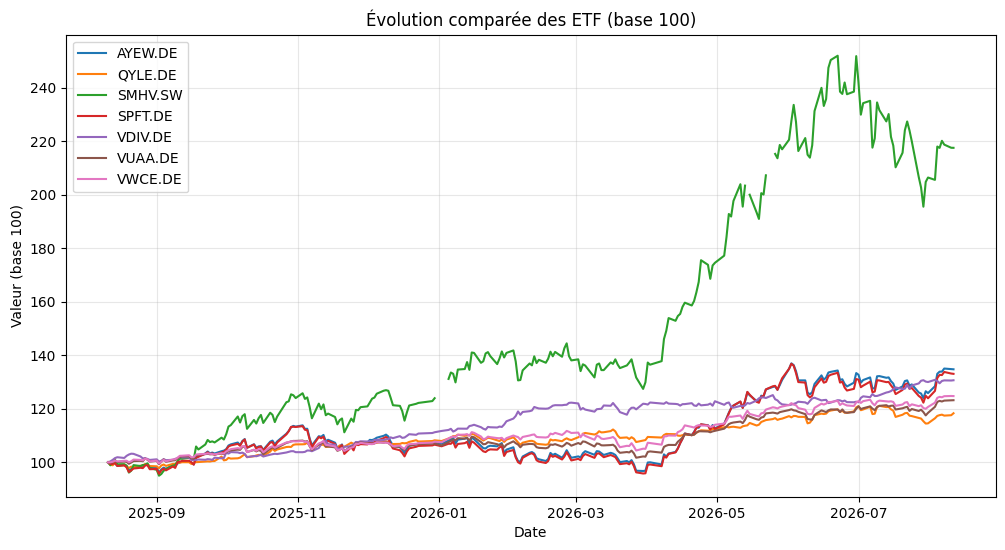

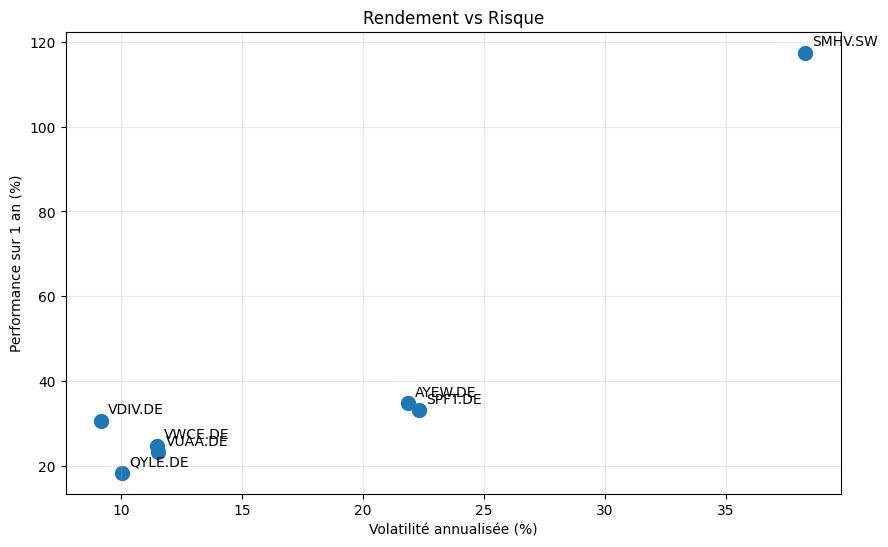

In [15]:
import matplotlib.pyplot as plt

# Graphique 1 : évolution normalisée des 7 ETF (base 100)
data_normalisee = (data / data.iloc[0]) * 100

plt.figure(figsize=(12, 6))
for ticker in data_normalisee.columns:
    plt.plot(data_normalisee.index, data_normalisee[ticker], label=ticker)
plt.title("Évolution comparée des ETF (base 100)")
plt.xlabel("Date")
plt.ylabel("Valeur (base 100)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Graphique 2 : rendement vs volatilité (nuage de points)
plt.figure(figsize=(10, 6))
plt.scatter(volatilite * 100, performance_totale, s=100)
for ticker in tickers:
    plt.annotate(ticker, (volatilite[ticker] * 100, performance_totale[ticker]),
                 xytext=(5, 5), textcoords="offset points")
plt.title("Rendement vs Risque")
plt.xlabel("Volatilité annualisée (%)")
plt.ylabel("Performance sur 1 an (%)")
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
import smtplib
from email.mime.multipart import MIMEMultipart
from email.mime.text import MIMEText
from google.colab import userdata

mot_de_passe = userdata.get('GMAIL_APP_PASSWORD')
mon_email = "TON_ADRESSE_GMAIL@gmail.com"  # celle qui a généré le mot de passe d'application
destinataire = "TON_ADRESSE_YAHOO@yahoo.com"

# Recalcule les métriques (au cas où data aurait changé depuis la dernière session)
rendements = data.pct_change().dropna()
performance_totale = (data.iloc[-1] / data.iloc[0] - 1) * 100
volatilite = rendements.std() * (252 ** 0.5)
sharpe = (performance_totale / 100) / volatilite
cumul_max = data.cummax()
drawdown = (data - cumul_max) / cumul_max
drawdown_max = drawdown.min() * 100

# Construction du corps de l'email
corps = "Rapport quotidien - Portefeuille ETF\n\n"
corps += f"{'Ticker':<12}{'Perf 1an %':<14}{'Volatilite %':<16}{'Sharpe':<10}{'Drawdown Max %':<16}\n"
corps += "-" * 68 + "\n"
for ticker in tickers:
    corps += f"{ticker:<12}{performance_totale[ticker]:<14.2f}{volatilite[ticker]*100:<16.2f}{sharpe[ticker]:<10.2f}{drawdown_max[ticker]:<16.2f}\n"

# Construction de l'email
msg = MIMEMultipart()
msg["From"] = mon_email
msg["To"] = destinataire
msg["Subject"] = "Rapport ETF automatisé"
msg.attach(MIMEText(corps, "plain"))

# Envoi
with smtplib.SMTP("smtp.gmail.com", 587) as serveur:
    serveur.starttls()
    serveur.login(mon_email, mot_de_passe)
    serveur.send_message(msg)

print("Email envoyé avec succès")

/tmp/ipykernel_755/2515951155.py:11: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  rendements = data.pct_change().dropna()


Email envoyé avec succès


In [18]:
!pip install schedule

In [20]:
import yfinance as yf
import pandas as pd
import smtplib
from email.mime.multipart import MIMEMultipart
from email.mime.text import MIMEText

def envoyer_rapport():
    # Recalcule les données et métriques
    data_actuelle = yf.download(tickers, period="1y")["Close"]
    rendements = data_actuelle.pct_change().dropna()
    performance_totale = (data_actuelle.iloc[-1] / data_actuelle.iloc[0] - 1) * 100
    volatilite = rendements.std() * (252 ** 0.5)
    sharpe = (performance_totale / 100) / volatilite
    cumul_max = data_actuelle.cummax()
    drawdown = (data_actuelle - cumul_max) / cumul_max
    drawdown_max = drawdown.min() * 100

    # Construit le corps de l'email
    corps = "Rapport quotidien - Portefeuille ETF\n\n"
    corps += f"{'Ticker':<12}{'Perf 1an %':<14}{'Volatilite %':<16}{'Sharpe':<10}{'Drawdown Max %':<16}\n"
    corps += "-" * 68 + "\n"
    for ticker in tickers:
        corps += f"{ticker:<12}{performance_totale[ticker]:<14.2f}{volatilite[ticker]*100:<16.2f}{sharpe[ticker]:<10.2f}{drawdown_max[ticker]:<16.2f}\n"

    # Construit l'email
    msg = MIMEMultipart()
    msg["From"] = mon_email
    msg["To"] = destinataire
    msg["Subject"] = "Rapport ETF automatisé"
    msg.attach(MIMEText(corps, "plain"))

    # Envoie l'email
    with smtplib.SMTP("smtp.gmail.com", 587) as serveur:
        serveur.starttls()
        serveur.login(mon_email, mot_de_passe)
        serveur.send_message(msg)

    print("Email envoyé avec succès")

In [21]:
envoyer_rapport()

/tmp/ipykernel_755/3906492018.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_actuelle = yf.download(tickers, period="1y")["Close"]
[*********************100%***********************]  7 of 7 completed
/tmp/ipykernel_755/3906492018.py:10: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  rendements = data_actuelle.pct_change().dropna()


Email envoyé avec succès


In [ ]:
import schedule
import time

def envoyer_rapport():
    # Recalcule les métriques
    data_actuelle = yf.download(tickers, period="1y")["Close"]
    rendements = data_actuelle.pct_change().dropna()
    performance_totale = (data_actuelle.iloc[-1] / data_actuelle.iloc[0] - 1) * 100
    volatilite = rendements.std() * (252 ** 0.5)
    sharpe = (performance_totale / 100) / volatilite
    cumul_max = data_actuelle.cummax()
    drawdown = (data_actuelle - cumul_max) / cumul_max
    drawdown_max = drawdown.min() * 100

    corps = "Rapport quotidien - Portefeuille ETF\n\n"
    corps += f"{'Ticker':<12}{'Perf 1an %':<14}{'Volatilite %':<16}{'Sharpe':<10}{'Drawdown Max %':<16}\n"
    corps += "-" * 68 + "\n"
    for ticker in tickers:
        corps += f"{ticker:<12}{performance_totale[ticker]:<14.2f}{volatilite[ticker]*100:<16.2f}{sharpe[ticker]:<10.2f}{drawdown_max[ticker]:<16.2f}\n"

    msg = MIMEMultipart()
    msg["From"] = mon_email
    msg["To"] = destinataire
    msg["Subject"] = "Rapport ETF automatisé"
    msg.attach(MIMEText(corps, "plain"))

    with smtplib.SMTP("smtp.gmail.com", 587) as serveur:
        serveur.starttls()
        serveur.login(mon_email, mot_de_passe)
        serveur.send_message(msg)

    print(f"Email envoyé à {time.strftime('%Y-%m-%d %H:%M:%S')}")

# Programme l'envoi tous les jours à 8h00
schedule.every().day.at("08:00").do(envoyer_rapport)

# Pour tester rapidement sans attendre 8h, décommente la ligne suivante :
# envoyer_rapport()

print("Programmation active. En attente...")
while True:
    schedule.run_pending()
    time.sleep(60)  # vérifie toutes les 60 secondes s'il est l'heure

Programmation active. En attente...
